In [1]:
!pip install torch_geometric ViennaRNA  

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 33.0 MB/s eta 0:00:0000:0100:01


In [2]:
import numpy as np
import pandas as pd
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import os
import gc
import random
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [5]:
df = pd.read_json('/kaggle/input/competitions/stanford-covid-vaccine/train.json', lines=True)
test_df = pd.read_json('/kaggle/input/competitions/stanford-covid-vaccine/test.json', lines=True)

In [6]:
train_df = df.copy()
eda_df = df.copy()

In [18]:
eda_df.head()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,index,id,sequence,structure,predicted_loop_type,signal_to_noise,SN_filter,seq_length,seq_scored,reactivity_error,...,reactivity,deg_Mg_pH10,deg_pH10,deg_Mg_50C,deg_50C,reactivity_mean,deg_MG_ph10_mean,deg_Mg_50C_mean,deg_pH10_mean,deg_50C_mean
0,0,id_001f94081,GGAAAAGCUCUAAUAACAGGAGACUAGGACUACGUAUUUCUAGGUA...,.....((((((.......)))).)).((.....((..((((((......,EEEEESSSSSSHHHHHHHSSSSBSSXSSIIIIISSIISSSSSSHHH...,6.894,1,107,68,"[0.1359, 0.20700000000000002, 0.1633, 0.1452, ...",...,"[0.3297, 1.5693000000000001, 1.1227, 0.8686, 0...","[0.7556, 2.983, 0.2526, 1.3789, 0.637600000000...","[2.3375, 3.5060000000000002, 0.3008, 1.0108, 0...","[0.35810000000000003, 2.9683, 0.2589, 1.4552, ...","[0.6382, 3.4773, 0.9988, 1.3228, 0.78770000000...",0.502631,0.559628,0.538540,0.503501,0.585893
1,1,id_0049f53ba,GGAAAAAGCGCGCGCGGUUAGCGCGCGCUUUUGCGCGCGCUGUACC...,.....(((((((((((((((((((((((....)))))))))).)))...,EEEEESSSSSSSSSSSSSSSSSSSSSSSHHHHSSSSSSSSSSBSSS...,0.193,0,107,68,"[2.8272, 2.8272, 2.8272, 4.7343, 2.5676, 2.567...",...,"[0.0, 0.0, 0.0, 2.2965, 0.0, 0.0, 0.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4.947, 4.4523, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4.8511, 4.0426, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[7.6692, 0.0, 10.9561, 0.0, 0.0, 0.0, 0.0, 0.0...",0.411401,0.698354,0.930103,0.846041,0.865125
2,2,id_006f36f57,GGAAAGUGCUCAGAUAAGCUAAGCUCGAAUAGCAAUCGAAUAGAAU...,.....((((.((.....((((.(((.....)))..((((......)...,EEEEESSSSISSIIIIISSSSMSSSHHHHHSSSMMSSSSHHHHHHS...,8.800,1,107,68,"[0.0931, 0.13290000000000002, 0.11280000000000...",...,"[0.44820000000000004, 1.4822, 1.1819, 0.743400...","[0.2504, 1.4021, 0.9804, 0.49670000000000003, ...","[2.243, 2.9361, 1.0553, 0.721, 0.6396000000000...","[0.5163, 1.6823000000000001, 1.0426, 0.7902, 0...","[0.9501000000000001, 1.7974999999999999, 1.499...",0.433966,0.578362,0.570284,0.548174,0.575172
3,3,id_0082d463b,GGAAAAGCGCGCGCGCGCGCGCGAAAAAGCGCGCGCGCGCGCGCGC...,......((((((((((((((((......))))))))))))))))((...,EEEEEESSSSSSSSSSSSSSSSHHHHHHSSSSSSSSSSSSSSSSSS...,0.104,0,107,68,"[3.5229, 6.0748, 3.0374, 3.0374, 3.0374, 3.037...",...,"[0.0, 2.2399, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....","[0.0, -0.5083, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[3.4248, 6.8128, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.8365, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[7.6692, -1.3223, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",0.329059,0.826485,1.221297,1.051551,0.696476
4,4,id_0087940f4,GGAAAAUAUAUAAUAUAUUAUAUAAAUAUAUUAUAGAAGUAUAAUA...,.....(((((((.((((((((((((.(((((((((....)))))))...,EEEEESSSSSSSBSSSSSSSSSSSSBSSSSSSSSSHHHHSSSSSSS...,0.423,0,107,68,"[1.665, 2.1728, 2.0041, 1.2405, 0.620200000000...",...,"[0.8267, 2.6577, 2.8481, 0.40090000000000003, ...","[2.1058, 3.138, 2.5437000000000003, 1.0932, 0....","[4.7366, 4.6243, 1.2068, 1.1538, 0.0, 0.0, 0.7...","[2.2052, 1.7947000000000002, 0.7457, 3.1233, 0...","[0.0, 5.1198, -0.3551, -0.3518, 0.0, 0.0, 0.0,...",0.282204,0.469587,0.393072,0.384826,0.440115


In [3]:
# Среднее реакционная способность
eda_df['reactivity_mean'] = eda_df["reactivity"].apply(lambda x: np.mean(x))
eda_df['deg_MG_ph10_mean'] = eda_df["deg_Mg_pH10"].apply(lambda x: np.mean(x))
eda_df['deg_Mg_50C_mean'] = eda_df["deg_Mg_50C"].apply(lambda x: np.mean(x))
eda_df['deg_pH10_mean'] = eda_df["deg_pH10"].apply(lambda x: np.mean(x))
eda_df['deg_50C_mean'] = eda_df["deg_50C"].apply(lambda x: np.mean(x))

# Проверка длин последовательностей

In [4]:
print(f'уникальные длины последовательностей sequence: {eda_df['sequence'].apply(lambda x: len(x)).unique()}')
print(f'уникальные длины последовательностей structure: {eda_df['structure'].apply(lambda x: len(x)).unique()}')
print(f'уникальные длины последовательностей predicted_loop_type: {eda_df['predicted_loop_type'].apply(lambda x: len(x)).unique()}')


уникальные длины последовательностей sequence: [107]
уникальные длины последовательностей structure: [107]
уникальные длины последовательностей predicted_loop_type: [107]


# Типы данных

In [65]:
eda_df.dtypes

index                    int64
id                      object
sequence                object
structure               object
predicted_loop_type     object
signal_to_noise        float64
SN_filter                int64
seq_length               int64
seq_scored               int64
reactivity_error        object
deg_error_Mg_pH10       object
deg_error_pH10          object
deg_error_Mg_50C        object
deg_error_50C           object
reactivity              object
deg_Mg_pH10             object
deg_pH10                object
deg_Mg_50C              object
deg_50C                 object
reactivity_mean        float64
deg_MG_ph10_mean       float64
deg_Mg_50C_mean        float64
deg_pH10_mean          float64
deg_50C_mean           float64
dtype: object

# Проверка на пропуски и согласованность значений¶
# Если seq_scored меньше seq_length — это значит, что для хвоста последовательности измерений нет, и в массивах могут быть пропуски. Их нужно найти и понять, как с ними быть.

In [68]:
print(f'Проверка на nan: {eda_df.isna().sum()}')
print('===================================================')
print(f'Проверка на null: {eda_df.isnull().sum()}')

Проверка на nan: index                  0
id                     0
sequence               0
structure              0
predicted_loop_type    0
signal_to_noise        0
SN_filter              0
seq_length             0
seq_scored             0
reactivity_error       0
deg_error_Mg_pH10      0
deg_error_pH10         0
deg_error_Mg_50C       0
deg_error_50C          0
reactivity             0
deg_Mg_pH10            0
deg_pH10               0
deg_Mg_50C             0
deg_50C                0
reactivity_mean        0
deg_MG_ph10_mean       0
deg_Mg_50C_mean        0
deg_pH10_mean          0
deg_50C_mean           0
dtype: int64
Проверка на null: index                  0
id                     0
sequence               0
structure              0
predicted_loop_type    0
signal_to_noise        0
SN_filter              0
seq_length             0
seq_scored             0
reactivity_error       0
deg_error_Mg_pH10      0
deg_error_pH10         0
deg_error_Mg_50C       0
deg_error_50C          0
re

In [69]:
eda_df[eda_df.seq_scored >= eda_df.seq_length] 

,index,id,sequence,structure,predicted_loop_type,signal_to_noise,SN_filter,seq_length,seq_scored,reactivity_error,...,reactivity,deg_Mg_pH10,deg_pH10,deg_Mg_50C,deg_50C,reactivity_mean,deg_MG_ph10_mean,deg_Mg_50C_mean,deg_pH10_mean,deg_50C_mean


# Проверка на распределение качества экспериментов

In [30]:
eda_df["signal_to_noise"].describe()

count    2400.000000
mean        4.530456
std         2.835142
min        -0.103000
25%         2.391000
50%         4.442500
75%         6.294250
max        17.194000
Name: signal_to_noise, dtype: float64

In [31]:
(eda_df["signal_to_noise"] > 1).value_counts()

signal_to_noise
True     2096
False     304
Name: count, dtype: int64

<Axes: xlabel='signal_to_noise', ylabel='reactivity_mean'>

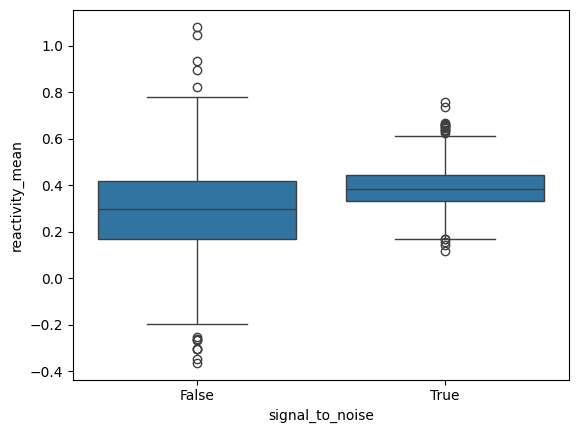

In [32]:
sns.boxplot(
    data=train_df,
    x=train_df["signal_to_noise"] > 1,
    y="reactivity_mean"
)

# Проверка на статистическое различие между группами

In [34]:
from scipy.stats import mannwhitneyu

group_false = eda_df.loc[
    eda_df["SN_filter"] == False,
    "reactivity_mean"
].dropna()

group_true = eda_df.loc[
    eda_df["SN_filter"] == True,
    "reactivity_mean"
].dropna()

stat, p_value = mannwhitneyu(
    group_false,
    group_true,
    alternative="two-sided"
)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 664497.0
p-value: 0.20936930549450572


In [6]:
eda_df1 = eda_df.copy()
eda_df0 = eda_df.copy()

eda_df0 = eda_df0[eda_df0['signal_to_noise'] > 1.0].reset_index(drop=True)



# Сравнительный EDA где есть зашумленные данные и без них

In [66]:
eda_df0.head()

,index,id,sequence,structure,predicted_loop_type,signal_to_noise,SN_filter,seq_length,seq_scored,reactivity_error,...,reactivity_mean,deg_MG_ph10_mean,deg_Mg_50C_mean,deg_pH10_mean,deg_50C_mean,A_count,C_count,G_count,U_count,GC_content
0,0,id_001f94081,GGAAAAGCUCUAAUAACAGGAGACUAGGACUACGUAUUUCUAGGUA...,.....((((((.......)))).)).((.....((..((((((......,EEEEESSSSSSHHHHHHHSSSSBSSXSSIIIIISSIISSSSSSHHH...,6.894,1,107,68,"[0.1359, 0.20700000000000002, 0.1633, 0.1452, ...",...,0.502631,0.559628,0.538540,0.503501,0.585893,45,23,19,20,0.392523
1,2,id_006f36f57,GGAAAGUGCUCAGAUAAGCUAAGCUCGAAUAGCAAUCGAAUAGAAU...,.....((((.((.....((((.(((.....)))..((((......)...,EEEEESSSSISSIIIIISSSSMSSSHHHHHSSSMMSSSSHHHHHHS...,8.800,1,107,68,"[0.0931, 0.13290000000000002, 0.11280000000000...",...,0.433966,0.578362,0.570284,0.548174,0.575172,43,20,24,20,0.411215
2,5,id_00ab2d761,GGAAAGCGCCGCGGCGGUAGCGGCAGCGAGGAGCGCUACCAAGGCA...,.....(.(((((.(((((((((...........)))))))..(((....,EEEEESISSSSSISSSSSSSSSHHHHHHHHHHHSSSSSSSMMSSSH...,4.136,1,107,68,"[0.1942, 0.2041, 0.1626, 0.1213, 0.10590000000...",...,0.286488,0.411699,0.325238,0.356634,0.304356,34,33,33,7,0.616822
3,6,id_00abef1d7,GGAAAACAAUUGCAUCGUUAGUACGACUCCACAGCGUAAGCUGUGG...,.........((((((((......((((((((((((....)))))))...,EEEEEEEEESSSSSSSSIIIIIISSSSSSSSSSSSHHHHSSSSSSS...,2.485,1,107,68,"[0.422, 0.5478000000000001, 0.4749000000000000...",...,0.349713,0.353104,0.367032,0.507000,0.383163,41,24,24,18,0.448598
4,7,id_00b436dec,GGAAAUCAUCGAGGACGGGUCCGUUCAGCACGCGAAAGCGUCGUGA...,.....(((((((((((..(((((((((..((((....))))..)))...,EEEEESSSSSSSSSSSIISSSSSSSSSIISSSSHHHHSSSSIISSS...,1.727,1,107,68,"[0.4843, 0.5233, 0.4554, 0.43520000000000003, ...",...,0.304882,0.443834,0.336829,0.331499,0.301346,37,27,28,15,0.514019


## Распределение нуклеотидов в тренировочном наборе данных

In [27]:
def cnt(x):
    nucle = 'ACGU'
    res = []
    for i in nucle:
        res.append(x.count(i))
    return res
    
sequnc0 = eda_df0.sequence.apply(cnt)
df_seq0 = pd.DataFrame(sequnc0.to_list(), columns=['A','C','G','U'])

sequnc1 = eda_df1.sequence.apply(cnt)
df_seq1 = pd.DataFrame(sequnc1.to_list(), columns=['A','C','G','U'])

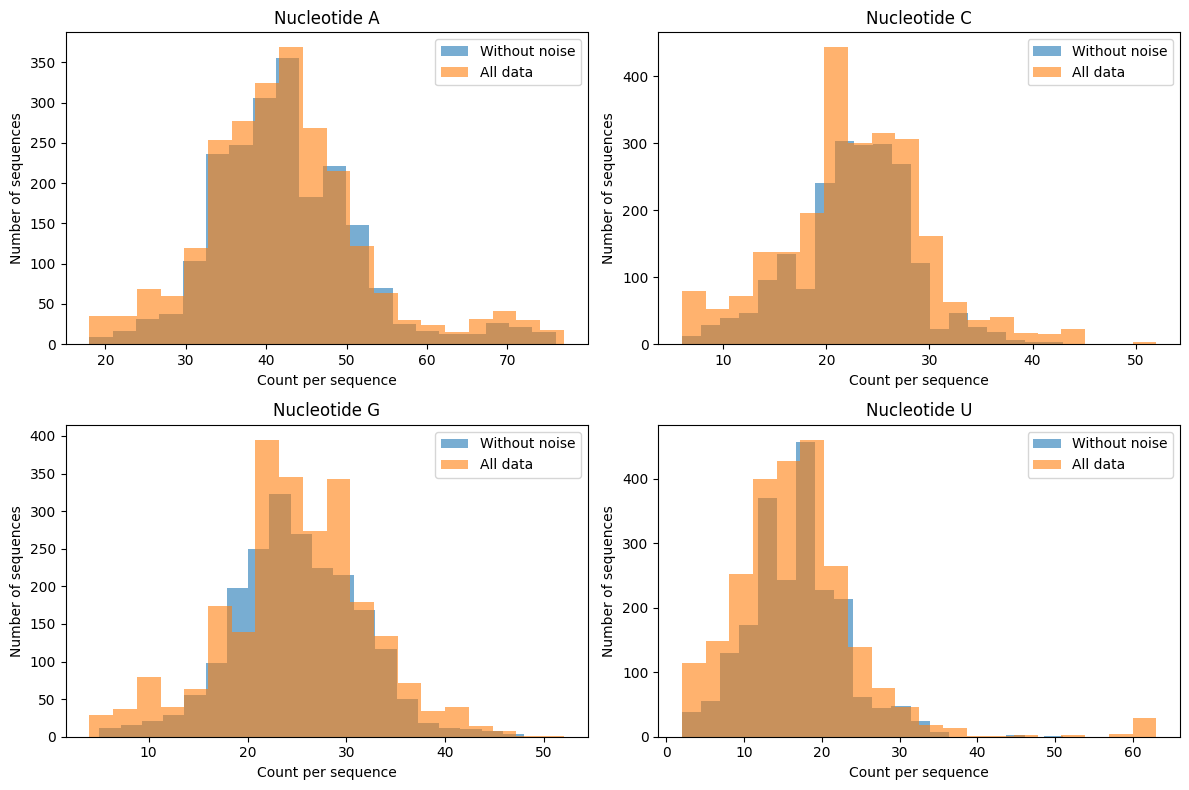

In [28]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

nucleotides = ['A', 'C', 'G', 'U']

for i, nucleotide in enumerate(nucleotides):
    row = i // 2
    col = i % 2
    
    ax[row, col].hist(
        df_seq0[nucleotide],
        bins=20,
        alpha=0.6,
        label = 'Without noise'
    )
    
    ax[row, col].hist(
        df_seq1[nucleotide],
        bins=20,
        alpha=0.6,
        label = 'All data'
    )
    
    ax[row, col].set_title(f'Nucleotide {nucleotide}')
    ax[row, col].set_xlabel('Count per sequence')
    ax[row, col].set_ylabel('Number of sequences')
    ax[row, col].legend()

plt.tight_layout()
plt.show()

In [29]:
counter0 = Counter()

for seq in eda_df0['sequence']:
    counter0.update(seq)

print(counter0)
print('================================================')

freq0 = pd.Series(counter0)

freq0 = freq0 / freq0.sum() * 100

print(freq0)

print('=================================================')
counter1 = Counter()

for seq in eda_df1['sequence']:
    counter1.update(seq)

print(counter1)
print('================================================')

freq1 = pd.Series(counter1)

freq1 = freq1 / freq1.sum() * 100

print(freq1)

Counter({'A': 89265, 'G': 52500, 'C': 47449, 'U': 35058})
G    23.409075
A    39.802115
C    21.156899
U    15.631911
dtype: float64
Counter({'A': 101699, 'G': 59443, 'C': 54614, 'U': 41044})
G    23.147586
A    39.602414
C    21.267134
U    15.982866
dtype: float64


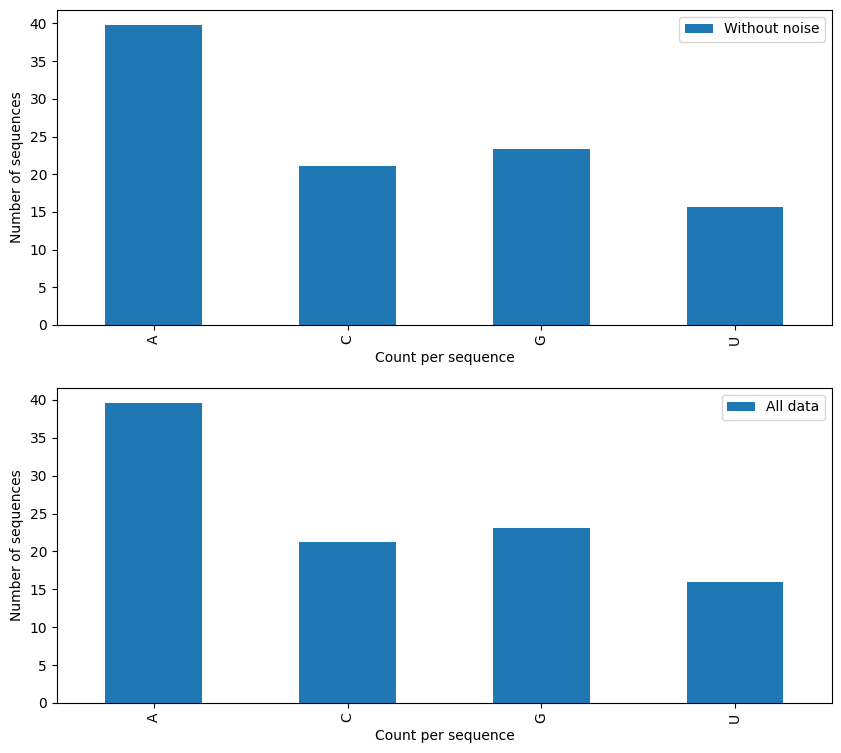

In [30]:
fig, ax = plt.subplots(2, 1, figsize=(10,9))

freq0.sort_index().plot.bar(ax = ax[0], label = 'Without noise')
freq1.sort_index().plot.bar(ax = ax[1], label = 'All data')

ax[0].set_xlabel('Count per sequence')
ax[0].set_ylabel('Number of sequences')
ax[0].legend()

ax[1].set_xlabel('Count per sequence')
ax[1].set_ylabel('Number of sequences')
ax[1].legend()

plt.show()

In [31]:
eda_df0['A_count'] = eda_df0['sequence'].apply(lambda x: x.count('A'))
eda_df0['C_count'] = eda_df0['sequence'].apply(lambda x: x.count('C'))
eda_df0['G_count'] = eda_df0['sequence'].apply(lambda x: x.count('G'))
eda_df0['U_count'] = eda_df0['sequence'].apply(lambda x: x.count('U'))

eda_df0[['A_count','C_count','G_count','U_count']].head()

eda_df1['A_count'] = eda_df1['sequence'].apply(lambda x: x.count('A'))
eda_df1['C_count'] = eda_df1['sequence'].apply(lambda x: x.count('C'))
eda_df1['G_count'] = eda_df1['sequence'].apply(lambda x: x.count('G'))
eda_df1['U_count'] = eda_df1['sequence'].apply(lambda x: x.count('U'))

eda_df1[['A_count','C_count','G_count','U_count']].head()

,A_count,C_count,G_count,U_count
0,45,23,19,20
1,25,32,33,17
2,43,20,24,20
3,28,35,35,9
4,58,6,6,37


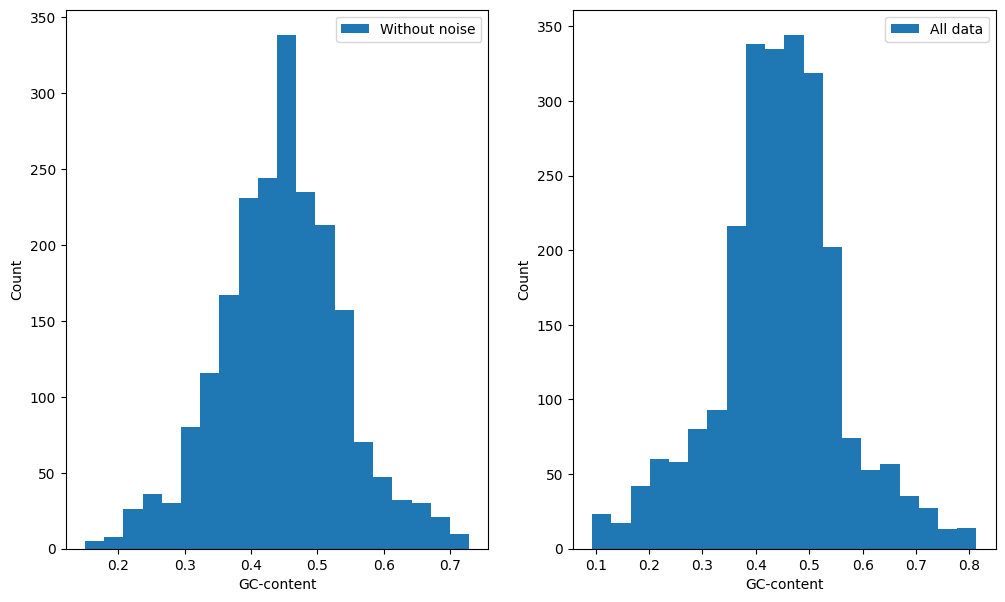

In [32]:
eda_df0['GC_content'] = eda_df0['sequence'].apply(
    lambda x: (x.count('G') + x.count('C')) / len(x)
)

eda_df1['GC_content'] = eda_df1['sequence'].apply(
    lambda x: (x.count('G') + x.count('C')) / len(x)
)

fig, ax = plt.subplots(1, 2, figsize=(12,7))
ax[0].hist(x=eda_df0['GC_content'],bins=20, label = 'Without noise')
ax[1].hist(x=eda_df1['GC_content'],bins=20, label = 'All data')
ax[0].set_xlabel("GC-content")
ax[0].set_ylabel("Count")
ax[0].legend()
ax[1].set_xlabel("GC-content")
ax[1].set_ylabel("Count")
ax[1].legend()
plt.show()

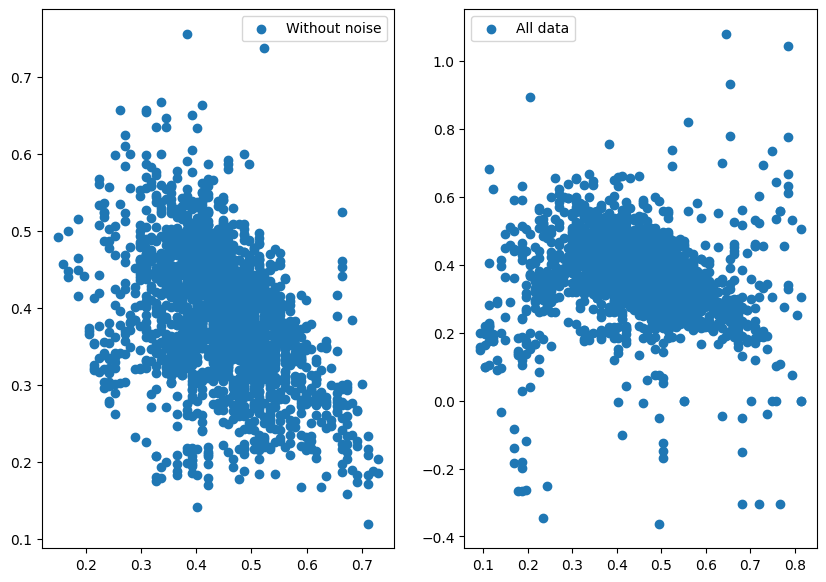

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(10,7))

ax[0].scatter(
    eda_df0["GC_content"],
    eda_df0["reactivity_mean"],
    label = 'Without noise'
)

ax[1].scatter(
    eda_df1["GC_content"],
    eda_df1["reactivity_mean"],
    label = 'All data'
)
ax[0].legend()
ax[1].legend()


## Частоты loop types

In [35]:
counter0 = Counter()

for seq in eda_df0['predicted_loop_type']:
    counter0.update(seq)

print(counter0)
print('================================================')

freq0 = pd.Series(counter0)

freq0 = freq0 / freq0.sum() * 100

print(freq0)

print('==================================================')

counter1 = Counter()

for seq in eda_df1['predicted_loop_type']:
    counter1.update(seq)

print(counter1)
print('================================================')

freq1 = pd.Series(counter1)

freq1 = freq1 / freq1.sum() * 100

print(freq1)

Counter({'S': 99990, 'E': 70445, 'H': 26118, 'I': 11778, 'X': 7471, 'M': 5585, 'B': 2885})
E    31.410519
S    44.584255
H    11.645680
B     1.286384
X     3.331223
I     5.251659
M     2.490280
dtype: float64
Counter({'S': 113536, 'E': 85634, 'H': 28624, 'I': 12187, 'X': 7959, 'M': 5792, 'B': 3068})
E    33.346573
S    44.211838
H    11.146417
B     1.194704
X     3.099299
I     4.745717
M     2.255452
dtype: float64


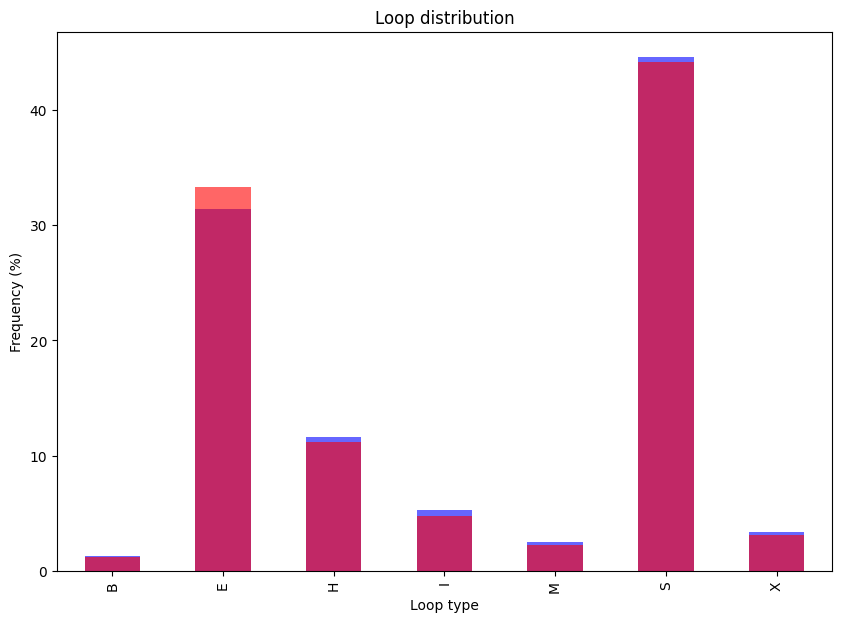

In [44]:
fig, ax = plt.subplots(figsize=(10,7))

freq0.sort_index().plot.bar(ax,alpha=0.6,color='b',label='Without noise')
freq1.sort_index().plot.bar(ax,alpha=0.6,color='r',label='All data')

plt.xlabel("Loop type")
plt.ylabel("Frequency (%)")
plt.title("Loop distribution")
plt.show()

## Для данных без шума

,reactivity_mean,deg_MG_ph10_mean,deg_Mg_50C_mean,deg_pH10_mean,deg_50C_mean
reactivity_mean,1.000000,0.643670,0.737488,0.706019,0.732031
deg_MG_ph10_mean,0.643670,1.000000,0.779615,0.698159,0.646038
deg_Mg_50C_mean,0.737488,0.779615,1.000000,0.810611,0.869845
deg_pH10_mean,0.706019,0.698159,0.810611,1.000000,0.816330
deg_50C_mean,0.732031,0.646038,0.869845,0.816330,1.000000


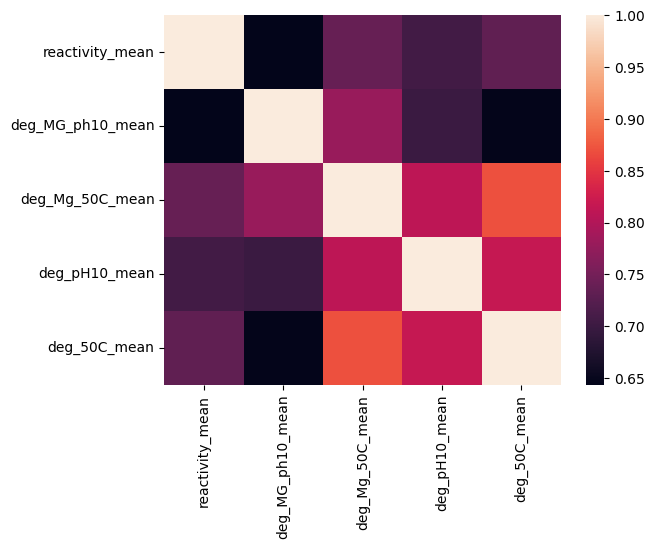

In [55]:
sns.heatmap(eda_df0[['reactivity_mean', 'deg_MG_ph10_mean', 'deg_Mg_50C_mean', 'deg_pH10_mean', 'deg_50C_mean']].corr())
eda_df0[['reactivity_mean', 'deg_MG_ph10_mean', 'deg_Mg_50C_mean', 'deg_pH10_mean', 'deg_50C_mean']].corr()

## Для всех данных

,reactivity_mean,deg_MG_ph10_mean,deg_Mg_50C_mean,deg_pH10_mean,deg_50C_mean
reactivity_mean,1.000000,0.624866,0.643631,0.574188,0.586047
deg_MG_ph10_mean,0.624866,1.000000,0.722604,0.586810,0.576362
deg_Mg_50C_mean,0.643631,0.722604,1.000000,0.647299,0.721753
deg_pH10_mean,0.574188,0.586810,0.647299,1.000000,0.664483
deg_50C_mean,0.586047,0.576362,0.721753,0.664483,1.000000


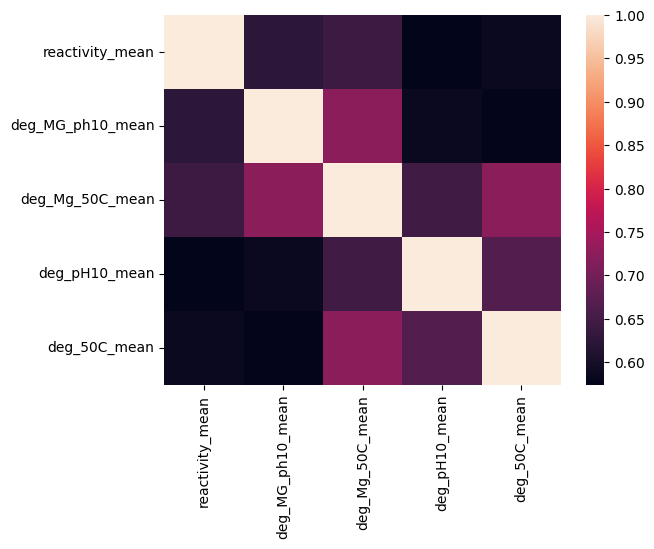

In [45]:
sns.heatmap(eda_df1[['reactivity_mean', 'deg_MG_ph10_mean', 'deg_Mg_50C_mean', 'deg_pH10_mean', 'deg_50C_mean']].corr())
eda_df1[['reactivity_mean', 'deg_MG_ph10_mean', 'deg_Mg_50C_mean', 'deg_pH10_mean', 'deg_50C_mean']].corr()

# Просмотр распределения нуклеотидов по позициям

In [10]:
rows = []

for _, row in train_df.iterrows():
    
    n = row['seq_scored']
    
    sequence = row['sequence'][:n]
    reactivity = row['reactivity'][:n]
    structure = row['structure'][:n]
    loop_type = row['predicted_loop_type'][:n]
    
    for position, (nucleotide, react, struct, loop) in enumerate(
        zip(sequence, reactivity, structure, loop_type),
        start=1
    ):
       rows.append({
                'id': row['id'],
                'position': position,
                'nucleotide': nucleotide,
                'reactivity': react,
                'structure': struct,
                'loop_type': loop,
                'paired': struct in ['(', ')'],
                'SN_filter': row['SN_filter']
            })

nucleotide_df = pd.DataFrame(rows)

# Статистики reactivity взависимости от позиции в наборе

In [5]:
nucleotide_df.groupby('position')['reactivity'].agg(
    ['mean', 'median', 'std']
)

,mean,median,std
position,,,
1,0.536378,0.50415,0.729612
2,1.513710,1.38345,1.266217
3,1.124513,1.15465,1.349776
4,0.833669,0.87385,1.729040
5,0.672602,0.59715,0.689051
...,...,...,...
64,0.303148,0.16785,0.707542
65,0.334632,0.20385,0.628050
66,0.403904,0.26415,0.658385


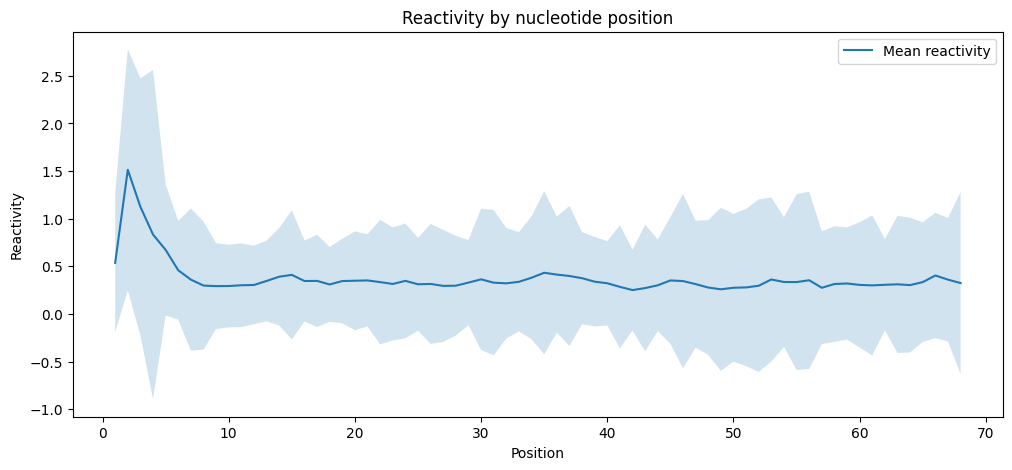

In [12]:
position_stats = (
    nucleotide_df
    .groupby('position')['reactivity']
    .agg(['mean', 'std'])
)

plt.figure(figsize=(12, 5))

plt.plot(
    position_stats.index,
    position_stats['mean'],
    label='Mean reactivity'
)

plt.fill_between(
    position_stats.index,
    position_stats['mean'] - position_stats['std'],
    position_stats['mean'] + position_stats['std'],
    alpha=0.2
)

plt.xlabel('Position')
plt.ylabel('Reactivity')
plt.title('Reactivity by nucleotide position')
plt.legend()
plt.show()


# **Среднее значение для нуклеотидов** 

In [6]:
nucleotide_df.groupby('nucleotide')['reactivity'].mean()

nucleotide
A    0.504686
C    0.148330
G    0.387155
U    0.330424
Name: reactivity, dtype: float64

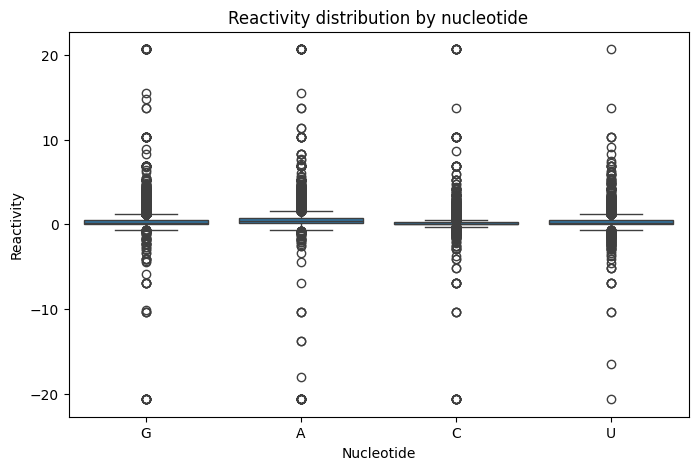

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=nucleotide_df,
    x='nucleotide',
    y='reactivity'
)

plt.xlabel('Nucleotide')
plt.ylabel('Reactivity')
plt.title('Reactivity distribution by nucleotide')
plt.show()

# В зависимости от структурного элемента

In [7]:
nucleotide_df.groupby('loop_type')['reactivity'].mean()

loop_type
B    0.628836
E    0.562947
H    0.677434
I    0.445707
M    0.522425
S    0.179080
X    0.472524
Name: reactivity, dtype: float64

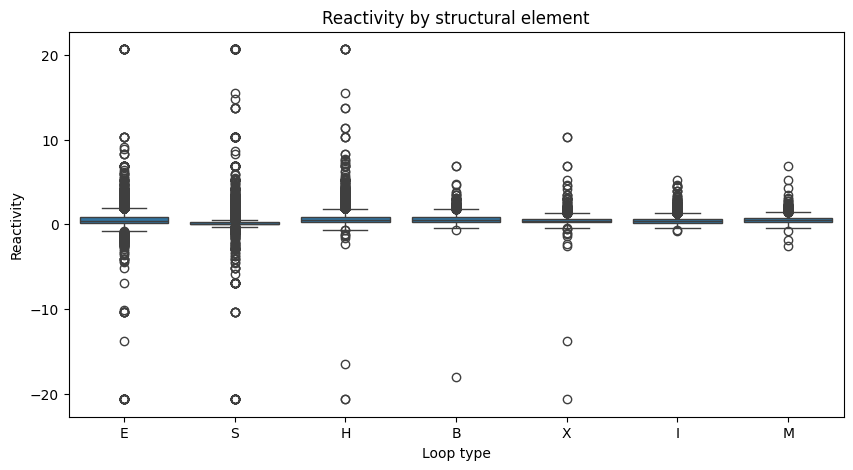

In [15]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=nucleotide_df,
    x='loop_type',
    y='reactivity'
)

plt.xlabel('Loop type')
plt.ylabel('Reactivity')
plt.title('Reactivity by structural element')

plt.show()

In [8]:
nucleotide_df.groupby(
    ['SN_filter', 'nucleotide']
)['reactivity'].mean()

SN_filter  nucleotide
0          A             0.464789
           C             0.152025
           G             0.402241
           U             0.313994
1          A             0.527541
           C             0.146727
           G             0.380739
           U             0.340567
Name: reactivity, dtype: float64

# Среднее reactivity от позиции и самого нуклеотида

In [9]:
nucleotide_df.groupby(
    ['position', 'nucleotide']
)['reactivity'].mean()

position  nucleotide
1         G             0.536378
2         G             1.513710
3         A             1.124513
4         A             0.833669
5         A             0.672602
                          ...   
67        U             0.426335
68        A             0.345618
          C             0.217332
          G             0.418815
          U             0.196868
Name: reactivity, Length: 257, dtype: float64

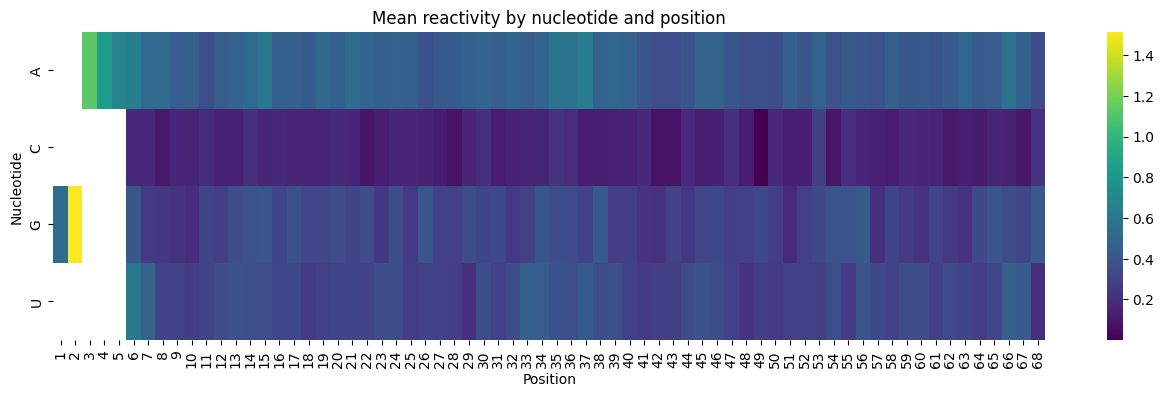

In [17]:
pivot = nucleotide_df.pivot_table(
    index='nucleotide',
    columns='position',
    values='reactivity',
    aggfunc='mean'
)

plt.figure(figsize=(16, 4))

sns.heatmap(
    pivot,
    cmap='viridis'
)

plt.xlabel('Position')
plt.ylabel('Nucleotide')
plt.title('Mean reactivity by nucleotide and position')

plt.show()

In [11]:
nucleotide_df.groupby('paired')['reactivity'].describe()

,count,mean,std,min,25%,50%,75%,max
paired,,,,,,,,
False,83267.0,0.562924,0.748719,-20.6648,0.1981,0.4325,0.7914,20.6668
True,79933.0,0.179080,0.644963,-20.6648,0.0112,0.0696,0.2268,20.6675


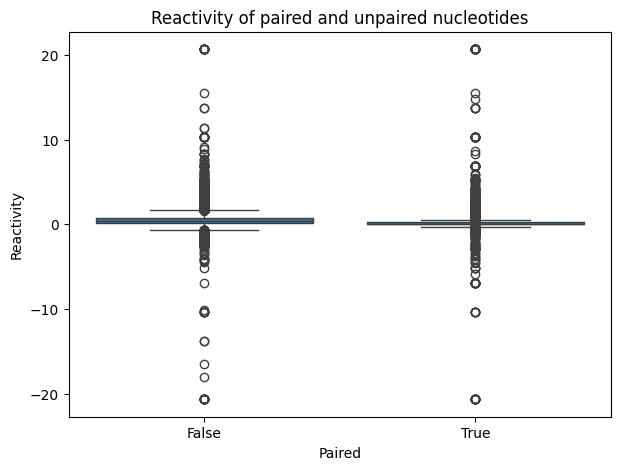

In [14]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=nucleotide_df,
    x='paired',
    y='reactivity'
)

plt.xlabel('Paired')
plt.ylabel('Reactivity')
plt.title('Reactivity of paired and unpaired nucleotides')

plt.show()

# Построение модели

## Базовая модель посчитать среднее по позиции и нуклеотиду

In [26]:


train_ids, val_ids = train_test_split(
    train_df['id'].unique(),
    test_size=0.2,
    random_state=42
)

df_train = train_df[
    train_df['id'].isin(train_ids)
].copy()

df_val = train_df[
    train_df['id'].isin(val_ids)
].copy()

In [27]:
def expand_dataset(df):
    
    rows = []

    targets = [
        'reactivity',
        'deg_Mg_pH10',
        'deg_Mg_50C',
        'deg_pH10',
        'deg_50C'
    ]

    for _, row in df.iterrows():

        n = int(row['seq_scored'])

        sequence = row['sequence'][:n]
        structure = row['structure'][:n]
        loop_type = row['predicted_loop_type'][:n]

        for position in range(n):

            struct = structure[position]

            rows.append({
                'id': row['id'],
                'position': position + 1,
                'nucleotide': sequence[position],
                'structure': struct,
                'loop_type': loop_type[position],
                'paired': struct in ['(', ')'],

                'reactivity': row['reactivity'][position],
                'deg_Mg_pH10': row['deg_Mg_pH10'][position],
                'deg_Mg_50C': row['deg_Mg_50C'][position],
                'deg_pH10': row['deg_pH10'][position],
                'deg_50C': row['deg_50C'][position]
            })

    return pd.DataFrame(rows)

In [28]:
baseline_train = expand_dataset(df_train)
baseline_val = expand_dataset(df_val)

In [24]:
print(baseline_train.shape)
baseline_train.head()

(130560, 11)


,id,position,nucleotide,structure,loop_type,paired,reactivity,deg_Mg_pH10,deg_Mg_50C,deg_pH10,deg_50C
0,id_001f94081,1,G,.,E,False,0.3297,0.7556,0.3581,2.3375,0.6382
1,id_001f94081,2,G,.,E,False,1.5693,2.9830,2.9683,3.5060,3.4773
2,id_001f94081,3,A,.,E,False,1.1227,0.2526,0.2589,0.3008,0.9988
3,id_001f94081,4,A,.,E,False,0.8686,1.3789,1.4552,1.0108,1.3228
4,id_001f94081,5,A,.,E,False,0.7217,0.6376,0.7244,0.2635,0.7877


In [30]:
features = [
    'position',
    'nucleotide',
    'structure',
    'loop_type'
]

targets = [
    'reactivity',
    'deg_Mg_pH10',
    'deg_Mg_50C',
    'deg_pH10',
    'deg_50C'
]


model_1 = (
    baseline_train
    .groupby('position')[targets]
    .mean()
    .reset_index()
)

model_2 = (
    baseline_train
    .groupby(
        ['position', 'nucleotide']
    )[targets]
    .mean()
    .reset_index()
)

model_3 = (
    baseline_train
    .groupby(
        ['position', 'nucleotide', 'structure', 'loop_type']
    )[targets]
    .mean()
    .reset_index()
)

In [26]:
def predict_baseline(
    df,
    model_3,
    model_2,
    model_1
):
    
    result = df[
        ['id', 'position', 'nucleotide', 'structure', 'loop_type']
    ].copy()

    # Level 1
    result = result.merge(
        model_3,
        on=['position', 'nucleotide', 'structure', 'loop_type'],
        how='left',
        suffixes=('', '_l1')
    )

    # Level 2
    result = result.merge(
        model_2,
        on=['position', 'nucleotide'],
        how='left',
        suffixes=('_l1', '_l2')
    )

    # Level 3
    result = result.merge(
        model_1,
        on=['position'],
        how='left',
        suffixes=('_l2', '_l3')
    )

    return result

In [27]:
from sklearn.metrics import mean_absolute_error


pred_val = predict_baseline(baseline_val, model_3, model_2, model_1)

for target in targets:

    mae = mean_absolute_error(
        baseline_val[target],
        pred_val[target]
    )

    print(target, mae)

reactivity 0.329461976789088
deg_Mg_pH10 0.34385843054279003
deg_Mg_50C 0.350717191766876
deg_pH10 0.35936403937844674
deg_50C 0.35319030483111213


In [28]:
pred_val

,id,position,nucleotide,structure,loop_type,reactivity_l1,deg_Mg_pH10_l1,deg_Mg_50C_l1,deg_pH10_l1,deg_50C_l1,reactivity_l2,deg_Mg_pH10_l2,deg_Mg_50C_l2,deg_pH10_l2,deg_50C_l2,reactivity,deg_Mg_pH10,deg_Mg_50C,deg_pH10,deg_50C
0,id_01f38f83d,1,G,.,E,0.522560,0.588418,0.468367,2.004734,0.614883,0.522632,0.587928,0.468058,2.005345,0.614803,0.522632,0.587928,0.468058,2.005345,0.614803
1,id_01f38f83d,2,G,.,E,1.499091,2.071375,2.010821,2.890728,1.788309,1.498831,2.070876,2.010275,2.889845,1.787336,1.498831,2.070876,2.010275,2.889845,1.787336
2,id_01f38f83d,3,A,.,E,1.112541,0.716567,0.948846,0.914417,0.989065,1.112905,0.717641,0.948361,0.914619,0.989868,1.112905,0.717641,0.948361,0.914619,0.989868
3,id_01f38f83d,4,A,.,E,0.839918,0.557222,0.747506,0.783479,0.789886,0.840528,0.557143,0.747462,0.783329,0.790148,0.840528,0.557143,0.747462,0.783329,0.790148
4,id_01f38f83d,5,A,.,E,0.673776,0.695279,0.854579,0.737145,0.741702,0.673826,0.695063,0.853315,0.736257,0.740559,0.673826,0.695063,0.853315,0.736257,0.740559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32635,id_ffe06f3fe,64,G,.,X,0.499699,0.775420,0.841321,0.897995,0.668127,0.343958,0.540434,0.450218,0.487849,0.504552,0.305884,0.520442,0.486225,0.459370,0.428930
32636,id_ffe06f3fe,65,C,.,X,0.292471,0.588307,0.647331,0.623200,0.566269,0.158006,0.411457,0.415225,0.417478,0.368230,0.326544,0.603067,0.570489,0.484086,0.431071
32637,id_ffe06f3fe,66,A,.,X,0.682191,0.737972,0.840151,0.568400,0.674678,0.567309,0.620773,0.709458,0.470528,0.543112,0.405776,0.568541,0.572736,0.462020,0.531057
32638,id_ffe06f3fe,67,U,.,X,0.557193,0.826262,0.687652,0.605506,0.619699,0.415843,0.612162,0.505738,0.474657,0.456485,0.359599,0.493412,0.500752,0.429149,0.453703


# LightGBM

In [32]:
X_train = pd.get_dummies(
    baseline_train[features],
    columns=['nucleotide', 'structure', 'loop_type']
)

X_val = pd.get_dummies(
    baseline_val[features],
    columns=['nucleotide', 'structure', 'loop_type']
)

X_val = X_val.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [33]:
from lightgbm import LGBMRegressor

models = {}

for target in targets:

    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        random_state=42
    )

    model.fit(
        X_train,
        baseline_train[target]
    )

    models[target] = model

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 97
[LightGBM] [Info] Number of data points in the train set: 130560, number of used features: 15
[LightGBM] [Info] Start training from score 0.377036
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [35]:
predictions = {}

for target, model in models.items():

    predictions[target] = model.predict(X_val)

pred_df = pd.DataFrame(predictions)

In [53]:
from sklearn.metrics import mean_absolute_error

for target in targets:
    scr = {'reactivity':0,'deg_Mg_pH10':0,'deg_Mg_50C':0, 'deg_pH10':0, 'deg_50C':0}
    mae = mean_absolute_error(
        baseline_val[target],
        pred_df[target]
    )
    scr[target] = mae
    
    print(target, mae)
    
results.append({'LightGBM':scr})

reactivity 0.2738942666612707
deg_Mg_pH10 0.3189590738287803
deg_Mg_50C 0.31893650804133866
deg_pH10 0.3395910119100165
deg_50C 0.3280683920614934


In [36]:
SEQ_LEN = 68  # все последовательности имеют длину seq_scored = 68
NUM_TARGETS = 5  # reactivity, deg_Mg_pH10, deg_Mg_50C, deg_pH10, deg_50C

# Словари для one-hot кодирования
nuc_dict = {'A': 0, 'C': 1, 'G': 2, 'U': 3}
struct_dict = {'.': 0, '(': 1, ')': 2}  # основные символы структуры
# (можно добавить и другие, но для простоты ограничимся тремя)

def add_gc_content(seq, window=3):
    gc_features = []
    for i in range(len(seq)):
        start = max(0, i-window)
        end = min(len(seq), i+window+1)
        window_seq = seq[start:end]
        gc = (window_seq.count('G') + window_seq.count('C')) / len(window_seq)
        gc_features.append(gc)
    return np.array(gc_features, dtype=np.float32).reshape(-1, 1)


def sequence_to_features(row, GC_content=False):
    """
    Преобразует одну строку из DataFrame в тензор признаков (SEQ_LEN x num_features)
    и тензор целей (SEQ_LEN x NUM_TARGETS).
    """
    seq = row['sequence'][:SEQ_LEN]
    struct = row['structure'][:SEQ_LEN]
    # Целевые переменные
    targets = np.stack([
        row['reactivity'][:SEQ_LEN],
        row['deg_Mg_pH10'][:SEQ_LEN],
        row['deg_Mg_50C'][:SEQ_LEN],
        row['deg_pH10'][:SEQ_LEN],
        row['deg_50C'][:SEQ_LEN]
    ], axis=-1)  # форма (SEQ_LEN, 5)

    # Признаки
    # 1) One-hot нуклеотида (4 канала)
    nuc_onehot = np.zeros((SEQ_LEN, 4), dtype=np.float32)
    for i, ch in enumerate(seq):
        nuc_onehot[i, nuc_dict[ch]] = 1.0

    # 2) One-hot структуры (3 канала)
    struct_onehot = np.zeros((SEQ_LEN, 3), dtype=np.float32)
    for i, ch in enumerate(struct):
        struct_onehot[i, struct_dict.get(ch, 0)] = 1.0

    # 3) Позиционный признак (нормализованный от 0 до 1)
    position = np.arange(SEQ_LEN, dtype=np.float32).reshape(-1, 1) / SEQ_LEN

    if GC_content:
        gc_feat = add_gc_content(seq)
        features = np.concatenate([nuc_onehot, struct_onehot, position, gc_feat], axis=1)
        return features, targets
        
    # Объединяем все признаки по последней оси
    features = np.concatenate([nuc_onehot, struct_onehot, position], axis=1)  # (SEQ_LEN, 8)

    return features, targets

In [37]:
features_list = []
targets_list = []
ids_list = []

for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Processing sequences"):
    feat, targ = sequence_to_features(row)
    features_list.append(feat)
    targets_list.append(targ)
    ids_list.append(row['id'])

X = np.array(features_list)  # (N, SEQ_LEN, 8)
y = np.array(targets_list)   # (N, SEQ_LEN, 5)
ids = np.array(ids_list)

print(f"Features shape: {X.shape}, Targets shape: {y.shape}")


Processing sequences: 100%|██████████| 2400/2400 [00:00<00:00, 5108.58it/s]

Features shape: (2400, 68, 8), Targets shape: (2400, 68, 5)


In [38]:
unique_ids = np.unique(ids)
train_ids, val_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)

train_mask = np.isin(ids, train_ids)
val_mask = np.isin(ids, val_ids)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

print(f"Train samples: {X_train.shape[0]}, Val samples: {X_val.shape[0]}")

Train samples: 1920, Val samples: 480


In [39]:
class RNADataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]  # (SEQ_LEN, 8), (SEQ_LEN, 5)

batch_size = 64
train_dataset = RNADataset(X_train, y_train)
val_dataset = RNADataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [40]:
class RNAPredictor(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        # 1D свертка для извлечения локальных паттернов
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.dropout_conv = nn.Dropout(dropout)

        # BiLSTM для обработки последовательности
        self.lstm = nn.LSTM(input_size=64, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True,
                            bidirectional=True, dropout=dropout if num_layers > 1 else 0)

        # Выходной слой (применяется к каждому таймстепу)
        # Вход: hidden_dim * 2 (из-за bidirectional)
        self.fc = nn.Linear(hidden_dim * 2, NUM_TARGETS)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        # Переставляем для Conv1d: (batch, channels, seq_len)
        x = x.permute(0, 2, 1)
        x = F.relu(self.conv1(x))
        x = self.dropout_conv(x)
        x = F.relu(self.conv2(x))
        x = self.dropout_conv(x)
        # Обратно к (batch, seq_len, channels)
        x = x.permute(0, 2, 1)

        # LSTM
        x, _ = self.lstm(x)  # (batch, seq_len, hidden_dim*2)

        # Предсказания для каждой позиции
        out = self.fc(x)  # (batch, seq_len, 5)
        return out

model = RNAPredictor().to(device)
print(model)

# =============================================================================
# 7. Настройка оптимизатора и функции потерь
# =============================================================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
criterion = nn.MSELoss()  # или SmoothL1Loss

RNAPredictor(
  (conv1): Conv1d(8, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (dropout_conv): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)


In [41]:
num_epochs = 50
best_val_loss = float('inf')
patience = 10
patience_counter = 0

for epoch in range(1, num_epochs + 1):
    # ---- Train ----
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch} Train"):
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            val_loss += loss.item() * batch_x.size(0)
    val_loss /= len(val_loader.dataset)

    scheduler.step(val_loss)

    print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Сохранение лучшей модели
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  -> Best model saved (val_loss={val_loss:.6f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1 Train: 100%|██████████| 30/30 [00:04<00:00,  6.31it/s]


Epoch   1 | Train Loss: 0.976317 | Val Loss: 0.944985
  -> Best model saved (val_loss=0.944985)


Epoch 2 Train: 100%|██████████| 30/30 [00:04<00:00,  6.72it/s]


Epoch   2 | Train Loss: 0.905538 | Val Loss: 0.874708
  -> Best model saved (val_loss=0.874708)


Epoch 3 Train: 100%|██████████| 30/30 [00:04<00:00,  6.66it/s]


...

Epoch  48 | Train Loss: 0.767772 | Val Loss: 0.779116


Epoch 49 Train: 100%|██████████| 30/30 [00:04<00:00,  6.81it/s]


Epoch  49 | Train Loss: 0.759603 | Val Loss: 0.773982


Epoch 50 Train: 100%|██████████| 30/30 [00:04<00:00,  6.56it/s]


Epoch  50 | Train Loss: 0.750827 | Val Loss: 0.772241


In [55]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Собираем все предсказания на валидации
all_preds = []
all_targets = []
with torch.no_grad():
    for batch_x, batch_y in val_loader:
        batch_x = batch_x.to(device)
        preds = model(batch_x).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(batch_y.numpy())

all_preds = np.concatenate(all_preds, axis=0)  # (N_val, 68, 5)
all_targets = np.concatenate(all_targets, axis=0)

# Вычисляем MAE для каждого таргета
target_names = ['reactivity', 'deg_Mg_pH10', 'deg_Mg_50C', 'deg_pH10', 'deg_50C']
for i, name in enumerate(target_names):
    scr = {'reactivity':0,'deg_Mg_pH10':0,'deg_Mg_50C':0, 'deg_pH10':0, 'deg_50C':0}
    mae = mean_absolute_error(all_targets[:, :, i].flatten(), all_preds[:, :, i].flatten())
    scr[name] = mae
    print(f"MAE for {name}: {mae:.6f}")
results.append({'CNN+LSTM':scr})

MAE for reactivity: 0.206544
MAE for deg_Mg_pH10: 0.224502
MAE for deg_Mg_50C: 0.224854
MAE for deg_pH10: 0.273119
MAE for deg_50C: 0.257828


# Добавление новых признаков

In [43]:
features_list = []
targets_list = []
ids_list = []

for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Processing sequences"):
    feat, targ = sequence_to_features(row, GC_content=True)
    features_list.append(feat)
    targets_list.append(targ)
    ids_list.append(row['id'])

X = np.array(features_list)  # (N, SEQ_LEN, 8)
y = np.array(targets_list)   # (N, SEQ_LEN, 5)
ids = np.array(ids_list)

print(f"Features shape: {X.shape}, Targets shape: {y.shape}")


Processing sequences: 100%|██████████| 2400/2400 [00:00<00:00, 3120.33it/s]

Features shape: (2400, 68, 9), Targets shape: (2400, 68, 5)


In [44]:
unique_ids = np.unique(ids)
train_ids, val_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)

train_mask = np.isin(ids, train_ids)
val_mask = np.isin(ids, val_ids)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

print(f"Train samples: {X_train.shape[0]}, Val samples: {X_val.shape[0]}")

Train samples: 1920, Val samples: 480


In [45]:
class RNADataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]  

batch_size = 64
train_dataset = RNADataset(X_train, y_train)
val_dataset = RNADataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [46]:
class RNAPredictor(nn.Module):
    def __init__(self, input_dim=9, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        # 1D свертка для извлечения локальных паттернов
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(dropout)

        # BiLSTM для обработки последовательности
        self.lstm = nn.LSTM(input_size=256, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True,
                            bidirectional=True, dropout=dropout if num_layers > 1 else 0)

        # Выходной слой (применяется к каждому таймстепу)
        # Вход: hidden_dim * 2 (из-за bidirectional)
        self.fc = nn.Linear(hidden_dim * 2, NUM_TARGETS)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        # Переставляем для Conv1d: (batch, channels, seq_len)
        x = x.permute(0, 2, 1)
        res = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        # Conv block 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        # Conv block 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.dropout(x)

        x = x.permute(0, 2, 1)  # (batch, seq_len, 256)
        x, _ = self.lstm(x)
        return self.fc(x)
        

model = RNAPredictor().to(device)
print(model)

# =============================================================================
# 7. Настройка оптимизатора и функции потерь
# =============================================================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
criterion = nn.MSELoss()  # или SmoothL1Loss

RNAPredictor(
  (conv1): Conv1d(9, 64, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(256, 64, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)


In [47]:
num_epochs = 50
best_val_loss = float('inf')
patience = 10
patience_counter = 0

for epoch in range(1, num_epochs + 1):
    # ---- Train ----
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch} Train"):
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            val_loss += loss.item() * batch_x.size(0)
    val_loss /= len(val_loader.dataset)

    scheduler.step(val_loss)

    print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Сохранение лучшей модели
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  -> Best model saved (val_loss={val_loss:.6f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1 Train: 100%|██████████| 30/30 [00:08<00:00,  3.67it/s]


Epoch   1 | Train Loss: 0.897844 | Val Loss: 0.851122
  -> Best model saved (val_loss=0.851122)


Epoch 2 Train: 100%|██████████| 30/30 [00:08<00:00,  3.67it/s]


Epoch   2 | Train Loss: 0.826908 | Val Loss: 0.815102
  -> Best model saved (val_loss=0.815102)


Epoch 3 Train: 100%|██████████| 30/30 [00:08<00:00,  3.69it/s]


...

Epoch  40 | Train Loss: 0.713171 | Val Loss: 0.760430


Epoch 41 Train: 100%|██████████| 30/30 [00:08<00:00,  3.64it/s]


Epoch  41 | Train Loss: 0.710247 | Val Loss: 0.760723


Epoch 42 Train: 100%|██████████| 30/30 [00:08<00:00,  3.62it/s]


Epoch  42 | Train Loss: 0.711065 | Val Loss: 0.761932
Early stopping triggered.


In [64]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Собираем все предсказания на валидации
all_preds = []
all_targets = []
with torch.no_grad():
    for batch_x, batch_y in val_loader:
        batch_x = batch_x.to(device)
        preds = model(batch_x).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(batch_y.numpy())

all_preds = np.concatenate(all_preds, axis=0)  # (N_val, 68, 5)
all_targets = np.concatenate(all_targets, axis=0)

# Вычисляем MAE для каждого таргета
target_names = ['reactivity', 'deg_Mg_pH10', 'deg_Mg_50C', 'deg_pH10', 'deg_50C']
for i, name in enumerate(target_names):
    scr = {'reactivity':0,'deg_Mg_pH10':0,'deg_Mg_50C':0, 'deg_pH10':0, 'deg_50C':0}
    mae = mean_absolute_error(all_targets[:, :, i].flatten(), all_preds[:, :, i].flatten())
    scr[name] = mae
    print(f"MAE for {name}: {mae:.6f}")
results.append({'CNN+LSTM+GC_content':scr})

RuntimeError: Error(s) in loading state_dict for RNAPredictorGNN:
	Missing key(s) in state_dict: "convs.0.nn.0.weight", "convs.0.nn.0.bias", "convs.0.nn.2.weight", "convs.0.nn.2.bias", "convs.1.nn.0.weight", "convs.1.nn.0.bias", "convs.1.nn.2.weight", "convs.1.nn.2.bias", "convs.2.nn.0.weight", "convs.2.nn.0.bias", "convs.2.nn.2.weight", "convs.2.nn.2.bias", "bns.0.module.weight", "bns.0.module.bias", "bns.0.module.running_mean", "bns.0.module.running_var", "bns.1.module.weight", "bns.1.module.bias", "bns.1.module.running_mean", "bns.1.module.running_var", "bns.2.module.weight", "bns.2.module.bias", "bns.2.module.running_mean", "bns.2.module.running_var". 
	Unexpected key(s) in state_dict: "conv1.weight", "conv1.bias", "bn1.weight", "bn1.bias", "bn1.running_mean", "bn1.running_var", "bn1.num_batches_tracked", "conv2.weight", "conv2.bias", "bn2.weight", "bn2.bias", "bn2.running_mean", "bn2.running_var", "bn2.num_batches_tracked", "conv3.weight", "conv3.bias", "bn3.weight", "bn3.bias", "

# Использование графовой нейронной сети

In [16]:
from torch_geometric.nn import EdgeConv, global_mean_pool, BatchNorm, Sequential
from torch_geometric.data import Data, Dataset, DataLoader
from torch_geometric.utils import to_undirected, add_self_loops
import RNA

In [58]:
def build_rna_graph(seq, structure=None, edge_distance=4):
    """
    Строит граф для одной РНК-последовательности.
    
    Args:
        seq (str): последовательность РНК (A, C, G, U)
        structure (str, optional): строка вторичной структуры (. ( )). 
                                    Если None, предсказывается через ViennaRNA.
        edge_distance (int): радиус для соединения соседних нуклеотидов.
    
    Returns:
        torch_geometric.data.Data: объект графа.
    """
    seq_len = len(seq)
    
    # 1. Признаки узлов (One-hot нуклеотидов + позиция)
    nuc_dict = {'A': 0, 'C': 1, 'G': 2, 'U': 3}
    x = np.zeros((seq_len, 5), dtype=np.float32)
    for i, ch in enumerate(seq):
        x[i, nuc_dict[ch]] = 1.0
        x[i, 4] = i / seq_len  # нормализованная позиция
    
    # 2. Ребра (Edge Index)
    edge_index = []
    
    # 2a. Ребра по первичной структуре (соседи в пределах edge_distance)
    for i in range(seq_len):
        for j in range(max(0, i - edge_distance), min(seq_len, i + edge_distance + 1)):
            if i != j:
                edge_index.append([i, j])
    
    # 2b. Ребра по вторичной структуре (спаривание)
    if structure is None:
        # Предсказываем структуру через ViennaRNA, если она не дана
        ss, _ = RNA.fold(seq)
    else:
        ss = structure[:seq_len]  # обрезаем до длины seq_scored
    
    stack = []
    for i, ch in enumerate(ss):
        if ch == '(':
            stack.append(i)
        elif ch == ')':
            if stack:
                j = stack.pop()
                edge_index.append([i, j])
                edge_index.append([j, i])  # неориентированный граф
    
    # 2c. Преобразуем в тензор PyTorch и делаем граф неориентированным
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_index = to_undirected(edge_index)  # убеждаемся, что граф симметричен
    
    # 3. Создаем объект Data PyG
    x = torch.tensor(x, dtype=torch.float)
    data = Data(x=x, edge_index=edge_index)
    
    return data

In [59]:
class RNAGraphDataset(Dataset):
    def __init__(self, df, edge_distance=4, use_structure=True):
        """
        df: DataFrame с колонками 'sequence', 'structure', и таргетами
        """
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.edge_distance = edge_distance
        self.use_structure = use_structure
        self.target_cols = ['reactivity', 'deg_Mg_pH10', 'deg_Mg_50C', 'deg_pH10', 'deg_50C']
        
        # Предварительно строим все графы (ускоряет обучение)
        self.graphs = []
        self.targets = []
        for idx, row in tqdm(self.df.iterrows(), total=len(self.df), desc="Building graphs"):
            seq = row['sequence'][:68]
            struct = row['structure'][:68] if self.use_structure else None
            graph = build_rna_graph(seq, struct, self.edge_distance)
            
            # Целевые значения
            targets = np.stack([
                row['reactivity'][:68],
                row['deg_Mg_pH10'][:68],
                row['deg_Mg_50C'][:68],
                row['deg_pH10'][:68],
                row['deg_50C'][:68]
            ], axis=-1)  # (68, 5)
            
            # Добавляем маску валидных позиций (все позиции валидны, т.к. seq_scored = 68)
            graph.valid_mask = torch.ones(68, dtype=torch.bool)
            graph.y = torch.tensor(targets, dtype=torch.float)
            
            self.graphs.append(graph)
    
    def len(self):
        return len(self.graphs)
    
    def get(self, idx):
        return self.graphs[idx]

In [60]:

class RNAPredictorGNN(nn.Module):
    def __init__(self, in_channels=5, hidden_channels=128, out_channels=5, num_layers=3, dropout=0.3):
        super().__init__()
        
        # Создаем последовательность из EdgeConv слоев с BatchNorm
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        
        # Первый слой: in_channels -> hidden_channels
        self.convs.append(EdgeConv(nn.Sequential(
            nn.Linear(in_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )))
        self.bns.append(BatchNorm(hidden_channels))
        
        # Промежуточные слои: hidden_channels -> hidden_channels
        for _ in range(num_layers - 2):
            self.convs.append(EdgeConv(nn.Sequential(
                nn.Linear(hidden_channels * 2, hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, hidden_channels)
            )))
            self.bns.append(BatchNorm(hidden_channels))
        
        # Последний слой: hidden_channels -> hidden_channels (оставляем для гибкости)
        self.convs.append(EdgeConv(nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )))
        self.bns.append(BatchNorm(hidden_channels))
        
        # Выходной слой: hidden_channels -> out_channels (5)
        self.fc = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # Применяем каждый слой с Residual-связями (опционально)
        for i, (conv, bn) in enumerate(zip(self.convs, self.bns)):
            x_new = conv(x, edge_index)
            x_new = bn(x_new)
            x_new = F.relu(x_new)
            # Добавляем residual connection, если размерности совпадают
            if x.shape == x_new.shape:
                x = x + x_new
            else:
                x = x_new
            x = self.dropout(x)
        
        # Финальный линейный слой
        out = self.fc(x)  # (num_nodes, out_channels)
        return out

# Инициализация модели
model = RNAPredictorGNN(
    in_channels=5,
    hidden_channels=128,
    out_channels=5,
    num_layers=3,
    dropout=0.3
).to(device)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 118,149


In [61]:
# Подготовка данных
edge_distance = 4
full_dataset = RNAGraphDataset(train_df, edge_distance=edge_distance)

# Разделение на train/val с группировкой по id
unique_ids = train_df['id'].unique()
train_ids, val_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)

train_indices = [i for i, g in enumerate(full_dataset.graphs) if full_dataset.df.iloc[i]['id'] in train_ids]
val_indices = [i for i, g in enumerate(full_dataset.graphs) if full_dataset.df.iloc[i]['id'] in val_ids]

train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Настройка оптимизатора и функции потерь
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
criterion = nn.MSELoss()

# Цикл обучения
num_epochs = 50
best_val_loss = float('inf')
patience = 10
patience_counter = 0

for epoch in range(1, num_epochs + 1):
    # ---- Train ----
    model.train()
    train_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch} Train"):
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Предсказания для всех узлов графа (batch содержит несколько графов)
        out = model(batch)  # (total_nodes, 5)
        
        # Для каждого графа в батче нужна своя маска валидных позиций
        # В PyG батч содержит атрибут `batch` — индексы графов для каждого узла
        # Мы используем маску valid_mask, которую добавили в Dataset
        loss = criterion(out[batch.valid_mask], batch.y[batch.valid_mask])
        
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch.num_graphs
    
    train_loss /= len(train_loader.dataset)
    
    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            loss = criterion(out[batch.valid_mask], batch.y[batch.valid_mask])
            val_loss += loss.item() * batch.num_graphs
    val_loss /= len(val_loader.dataset)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    # Сохранение лучшей модели
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_gnn_model.pth')
        print(f"  -> Best model saved (val_loss={val_loss:.6f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1 Train: 100%|██████████| 60/60 [00:16<00:00,  3.74it/s]


Epoch   1 | Train Loss: 1.288925 | Val Loss: 0.904573
  -> Best model saved (val_loss=0.904573)


Epoch 2 Train: 100%|██████████| 60/60 [00:16<00:00,  3.75it/s]


Epoch   2 | Train Loss: 0.995226 | Val Loss: 0.893432
  -> Best model saved (val_loss=0.893432)


Epoch 3 Train: 100%|██████████| 60/60 [00:15<00:00,  3.83it/s]


...

Epoch  48 | Train Loss: 0.825020 | Val Loss: 0.820795


Epoch 49 Train: 100%|██████████| 60/60 [00:16<00:00,  3.73it/s]


Epoch  49 | Train Loss: 0.821352 | Val Loss: 0.819675


Epoch 50 Train: 100%|██████████| 60/60 [00:16<00:00,  3.73it/s]


Epoch  50 | Train Loss: 0.821052 | Val Loss: 0.831949


In [62]:
# Загрузка лучшей модели
model.load_state_dict(torch.load('best_gnn_model.pth'))
model.eval()

# Сбор предсказаний на валидации
all_preds = []
all_targets = []
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        out = model(batch)
        # Маска для извлечения только валидных позиций
        mask = batch.valid_mask
        all_preds.append(out[mask].cpu().numpy())
        all_targets.append(batch.y[mask].cpu().numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# MAE для каждого таргета
target_names = ['reactivity', 'deg_Mg_pH10', 'deg_Mg_50C', 'deg_pH10', 'deg_50C']
for i, name in enumerate(target_names):
    scr = {'reactivity':0,'deg_Mg_pH10':0,'deg_Mg_50C':0, 'deg_pH10':0, 'deg_50C':0}
    mae = mean_absolute_error(all_targets[:, i], all_preds[:, i])
    scr[name] = mae
    print(f"MAE for {name}: {mae:.6f}")

results.append({'GNN':scr})

MAE for reactivity: 0.253319
MAE for deg_Mg_pH10: 0.292162
MAE for deg_Mg_50C: 0.282160
MAE for deg_pH10: 0.312045
MAE for deg_50C: 0.302015


# Сравнение результатов

In [49]:

def evaluate_predictions(y_true, y_pred):

    scores = {}

    for target in targets:

        scores[target] = mean_absolute_error(
            y_true[target],
            y_pred[target]
        )

    scores['Mean_MAE'] = np.mean(list(scores.values()))

    return scores

In [51]:
results = []

In [63]:
results

[{'LightGBM': {'reactivity': 0,
   'deg_Mg_pH10': 0,
   'deg_Mg_50C': 0,
   'deg_pH10': 0,
   'deg_50C': 0.3280683920614934}},
 {'CNN+LSTM': {'reactivity': 0,
   'deg_Mg_pH10': 0,
   'deg_Mg_50C': 0,
   'deg_pH10': 0,
   'deg_50C': 0.2578284740447998}},
 {'CNN+LSTM+GC_content': 0.2578284740447998},
 {'GNN': {'reactivity': 0,
   'deg_Mg_pH10': 0,
   'deg_Mg_50C': 0,
   'deg_pH10': 0,
   'deg_50C': 0.3020145297050476}}]